In [5]:
from pathlib import Path
import pandas as pd 
import numpy as np 

DATA_DIR = Path("./data")
TRACK_DIR = DATA_DIR / "track_interval1h"
FORECAST_INIT_TIMES = {
    "24h": pd.Timestamp("2025-09-22 22:00"),
    "48h": pd.Timestamp("2025-09-21 22:00"),
}
MODEL_STYLES = {
    "era5": {"label": "ERA5_WRF", "color": "#4c78a8", "marker": "x"},
    "pangu": {"label": "Pangu_WRF", "color": "#f58518", "marker": "s"},
    "graphcast": {"label": "GraphCast_WRF", "color": "#54a24b", "marker": "^"},
    "fengwu": {"label": "FengWu_WRF", "color": "#e45756", "marker": "D"},
    "fuxi": {"label": "FuXi_WRF", "color": "#72b7b2", "marker": "v"},
    "aurora": {"label": "Aurora_WRF", "color": "#b279a2", "marker": "p"},
}


def load_track_forecast(model, cycle, init_time):
    values = np.loadtxt(TRACK_DIR / f"track_d01_interval1h_{model}_{cycle}.txt")
    lead_hour = np.arange(values.shape[0], dtype=int)
    return pd.DataFrame(
        {
            "model": model,
            "cycle": cycle,
            "lead_hour": lead_hour,
            "init_time": pd.Timestamp(init_time),
            "valid_time": pd.Timestamp(init_time) + pd.to_timedelta(lead_hour, unit="h"),
            "lon": values[:, 0],
            "lat": values[:, 1],
            "slp_hpa": values[:, 2],
        }
    )


track_forecasts = {
    cycle: {
        model: load_track_forecast(model, cycle, init_time)
        for model in MODEL_STYLES
    }
    for cycle, init_time in FORECAST_INIT_TIMES.items()
}

In [6]:
BEST_TRACK_FILE = DATA_DIR / "best_track_Ragasa_JMA.xlsx"


def load_best_track(file_path):
    return (
        pd.read_excel(file_path)
        .rename(
            columns={
                "Time": "time",
                "Lat": "lat_tenths",
                "Lon": "lon_tenths",
                "Pres": "pres_hpa",
                "Wind": "wind_kt",
            }
        )
        .assign(
            time=lambda df: pd.to_datetime(df["time"].astype(str), format="%y%m%d%H"),
            lat=lambda df: df["lat_tenths"] / 10,
            lon=lambda df: df["lon_tenths"] / 10,
        )
        [["time", "lat", "lon", "pres_hpa", "wind_kt"]]
    )


track_best = load_best_track(BEST_TRACK_FILE)

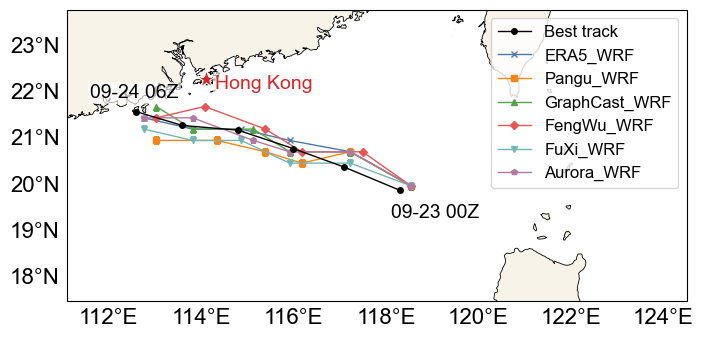

In [7]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 16

OUTPUT_DIR = Path(".")
HONG_KONG = {"lon": 114.1, "lat": 22.3}
TEXT_BBOX = {"facecolor": "white", "alpha": 0.65, "edgecolor": "none", "pad": 1.5}
TEXT_STYLE = {"fontname": "Arial", "fontsize": 14}
TICK_STYLE = {"size": 16, "family": "Arial"}
LEGEND_STYLE = {"family": "Arial", "size": 12}
TITLE_STYLE = {"fontname": "Arial", "fontsize": 18}
AXIS_LABEL_STYLE = {"fontname": "Arial", "fontsize": 16}


def prepare_cycle_plot(cycle):
    forecast_tracks = track_forecasts[cycle]
    forecast_start = FORECAST_INIT_TIMES[cycle]
    forecast_end = min(track["valid_time"].max() for track in forecast_tracks.values())

    best_track_window = (
        track_best.loc[track_best["time"].between(forecast_start, forecast_end)]
        .copy()
        .sort_values("time")
    )
    aligned_times = pd.Index(best_track_window["time"])

    forecast_aligned = {
        model: track.loc[track["valid_time"].isin(aligned_times)].copy().sort_values("valid_time")
        for model, track in forecast_tracks.items()
    }

    return {
        "cycle": cycle,
        "best_track": best_track_window,
        "forecast_aligned": forecast_aligned,
    }


def compute_extent(cycle_plot, pad=1.5):
    lon_series = [cycle_plot["best_track"]["lon"]]
    lat_series = [cycle_plot["best_track"]["lat"]]

    for forecast_track in cycle_plot["forecast_aligned"].values():
        lon_series.append(forecast_track["lon"] )
        lat_series.append(forecast_track["lat"] )

    lon_series.append(pd.Series([HONG_KONG["lon"]]))
    lat_series.append(pd.Series([HONG_KONG["lat"]]))

    all_lon = pd.concat(lon_series, ignore_index=True)
    all_lat = pd.concat(lat_series, ignore_index=True)
    return [all_lon.min() - pad, all_lon.max() + pad, all_lat.min() - pad, all_lat.max() + pad]


def compute_shared_extent(cycle_plot_map, pad=1.5):
    lon_series = [pd.Series([HONG_KONG["lon"]])]
    lat_series = [pd.Series([HONG_KONG["lat"]])]

    for cycle_plot in cycle_plot_map.values():
        lon_series.append(cycle_plot["best_track"]["lon"] )
        lat_series.append(cycle_plot["best_track"]["lat"] )

        for forecast_track in cycle_plot["forecast_aligned"].values():
            lon_series.append(forecast_track["lon"] )
            lat_series.append(forecast_track["lat"] )

    all_lon = pd.concat(lon_series, ignore_index=True)
    all_lat = pd.concat(lat_series, ignore_index=True)
    return [all_lon.min() - pad, all_lon.max() + pad, all_lat.min() - pad, all_lat.max() + pad]


def add_map_base(ax, extent):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="#f7f3e8")
    ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.6)

    gridliner = ax.gridlines(draw_labels=True, linewidth=0, color="none", alpha=0, linestyle="-")
    gridliner.top_labels = False
    gridliner.right_labels = False
    gridliner.xlines = False
    gridliner.ylines = False
    gridliner.xlabel_style = TICK_STYLE
    gridliner.ylabel_style = TICK_STYLE
    return gridliner


def add_axis_labels(ax, gridliner):
    # Draw the figure to compute gridliner label positions, then place axis labels outside them
    ax.get_figure().canvas.draw()
    renderer = ax.get_figure().canvas.get_renderer()

    # Compute bottom padding from x-tick labels
    x_pad = 0
    for label in gridliner.xlabel_artists:
        bb = label.get_window_extent(renderer).transformed(ax.transAxes.inverted())
        x_pad = max(x_pad, -bb.y0)

    # Compute left padding from y-tick labels
    y_pad = 0
    for label in gridliner.ylabel_artists:
        bb = label.get_window_extent(renderer).transformed(ax.transAxes.inverted())
        y_pad = max(y_pad, -bb.x0)


def add_annotations(ax, best_track_window):
    ax.scatter(
        HONG_KONG["lon"],
        HONG_KONG["lat"],
        color="#d62728",
        marker="*",
        s=180,
        facecolor="#d62728",
        edgecolor="white",
        linewidth=0.8,
        transform=ccrs.PlateCarree(),
        zorder=7,
    )
    ax.text(
        HONG_KONG["lon"] + 0.2,
        HONG_KONG["lat"] - 0.2,
        "Hong Kong",
        color="#d62728",
        transform=ccrs.PlateCarree(),
        zorder=7,
        bbox=TEXT_BBOX,
        **TEXT_STYLE,
    )

    start_row = best_track_window.iloc[0]
    ax.text(
        start_row["lon"] - 0.2,
        start_row["lat"] - 0.6,
        start_row["time"].strftime("%m-%d %HZ"),
        color="black",
        transform=ccrs.PlateCarree(),
        zorder=6,
        bbox=TEXT_BBOX,
        **TEXT_STYLE,
    )

    end_row = best_track_window.iloc[-1]
    ax.text(
        end_row["lon"] - 1.0,
        end_row["lat"] + 0.3,
        end_row["time"].strftime("%m-%d %HZ"),
        color="black",
        transform=ccrs.PlateCarree(),
        zorder=6,
        bbox=TEXT_BBOX,
        **TEXT_STYLE,
    )


def plot_track_map(cycle_plot, extent, output_name, title):
    fig = plt.figure(figsize=(8, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    gridliner = add_map_base(ax, extent)

    best_track_window = cycle_plot["best_track"]
    ax.plot(
        best_track_window["lon"],
        best_track_window["lat"],
        color="black",
        linewidth=1.0,
        marker="o",
        markersize=4.0,
        label="Best track",
        transform=ccrs.PlateCarree(),
        zorder=5,
    )

    for model, forecast_track in cycle_plot["forecast_aligned"].items():
        style = MODEL_STYLES[model]
        ax.plot(
            forecast_track["lon"],
            forecast_track["lat"],
            color=style["color"],
            linewidth=1.0,
            marker=style["marker"],
            markersize=4.0,
            label=style["label"],
            transform=ccrs.PlateCarree(),
            zorder=4,
        )

    add_annotations(ax, best_track_window)
    add_axis_labels(ax, gridliner)
    # ax.set_title(title, **TITLE_STYLE)
    ax.legend(loc="upper right", frameon=True, prop=LEGEND_STYLE)
 
    fig.savefig(OUTPUT_DIR / output_name, dpi=600, format="tif", bbox_inches="tight")
    plt.show()


cycle_plots = {cycle: prepare_cycle_plot(cycle) for cycle in FORECAST_INIT_TIMES}
shared_extent = compute_shared_extent(cycle_plots)
extent_24h = shared_extent
extent_48h = shared_extent
plot_track_map(cycle_plots["24h"], extent_24h, "track_forecast_24h.tif", "24-h forecast")

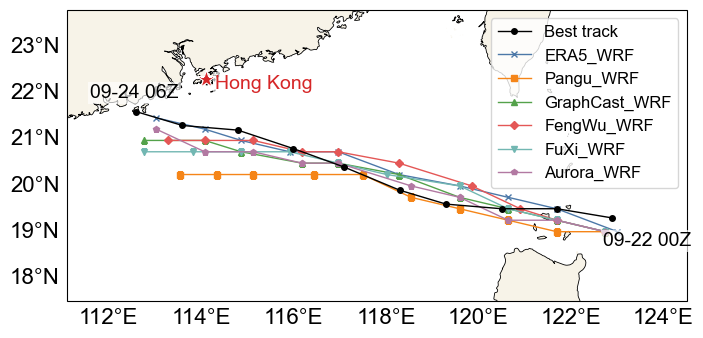

In [8]:
plot_track_map(cycle_plots["48h"], extent_48h, "track_forecast_48h.tif", "48-h forecast")